# 10 · Did the site redesign help? (no control group) — interrupted time series (CausalPy)

> **Runs in the `legacy` environment (pymc<6): `make env-legacy`, kernel `cmp-legacy`.**

**The business decision.** We redesigned the homepage on a known date, for **all** traffic at once — so,
unlike the DiD store rollout (notebook 08), there is **no control group** to compare against. Conversion
is up since the redesign. Is that real lift, or just the normal upward drift the site was already on?
Keep the redesign or roll it back?

### The idea: the past *is* the control group

When everyone is treated at the same moment, the only untreated comparison you have is **the treated unit's
own history**. **Interrupted time series (ITS)** uses it: fit the pre-change series — its **level**, its
**trend** (slope), and its **seasonality** (e.g. weekly cycles) — and then **extrapolate that fitted line
forward** past the change date. That extrapolation is the **counterfactual**: "what conversion *would* have
done if we'd changed nothing." The **gap** between actual conversion and this projection, after the change,
is the estimated effect.

Because it's a forecast, the counterfactual comes with a **credible band that widens the further out we
project** — an honest admission that "what would have happened" is less and less certain over time.

### The assumption and its checks

ITS is the *weakest* of the quasi-experiments because it leans entirely on **no concurrent shock**: nothing
*else* (a price change, a competitor move, a seasonality break) happened at the same date as the redesign,
or ITS will blame the redesign for it. We stress this with a **placebo-in-time** (pretend the change
happened earlier — the fake effect should be ≈ 0), track the **cumulative** impact, and check **residual
autocorrelation** (successive days being correlated, which — if ignored — makes the intervals look tighter
than they should).

> **On real data.** ITS fits any "everyone changed at once on a known date" event: a site redesign, a
> pricing change, a policy launch, a PR crisis. You need a reasonably long, stable **pre-period** and a
> clean intervention date. A famous public example is the effect of anti-smoking laws on cigarette sales.

It follows the repo's fixed **7-step contract**: question → simulate → identify → estimate → validate → decide in € → caveats.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore", category=FutureWarning)  # scope: hide only noisy library FutureWarnings, not correctness warnings
import causalpy as cp
from cmp import dgp, estimators as est, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
SEED = 31; REDESIGN = 120; TRUE = 0.03

## 2 · Simulate a ground truth

Daily conversion with a gentle upward trend and weekly seasonality. The redesign lands on **day
120** for everyone and adds a **true +3pp** step (~+30% relative on a ~10% base). The trend is the confounder (conversion was
already drifting up); the step is the effect.

**The data-generating model** — exactly what `dgp.its_redesign` implements (defaults & seed in
`src/cmp/dgp.py`). Days $t = 0,\dots,179$, redesign at day 120:

$$
Y_t = \underbrace{0.10 + 0.00015\,t}_{\text{level + trend}}
  + \underbrace{0.01\sin\!\big(\tfrac{2\pi t}{7}\big)}_{\text{weekly cycle}}
  + \underbrace{0.03\; \mathbf 1[t \ge 120]}_{\text{true step}}
  + \varepsilon_t,
\qquad \varepsilon_t \sim \mathcal N(0,\, 0.006^{2}).
$$

The pre-period drift is the confounder: $0.00015$ per day compounds to about $+1.8$pp over the
120-day pre-period, so a naive before/after mean comparison books trend the site was already on as
"redesign lift." ITS must fit that level + trend + weekly cycle on the pre-period and extrapolate
it, so that only the $0.03$ step remains as the effect.


In [2]:
df, true_lift, redesign_day = dgp.its_redesign(n_days=180, redesign_day=REDESIGN, true_lift=TRUE, seed=SEED)
df = df.set_index("t", drop=False)
print(f"TRUE redesign effect = +{true_lift*100:.0f}pp conversion from day {redesign_day}")
df.head()

TRUE redesign effect = +3pp conversion from day 120


,t,day,sin7,cos7,conversion
t,,,,,
0,0,0,0.000000,1.000000,0.097628
1,1,1,0.781831,0.623490,0.109552
2,2,2,0.974928,-0.222521,0.113692
3,3,3,0.433884,-0.900969,0.098956
4,4,4,-0.433884,-0.900969,0.100867


### 2b · The naive answer first — before/after books the trend as lift

The DGP math predicts exactly how the obvious dashboard number fails. A before/after difference of
means compares post-period days (centred on day $\approx 150$) with pre-period days (centred on day
$\approx 60$): under the $0.00015$/day drift those window centres sit $90$ days of trend apart, so
$0.00015 \times 90 \approx +1.35$pp of *pure pre-existing trend* gets booked as "redesign lift" on
top of the true $+3$pp. Compute it and watch — the ITS fit in Section 4 has to beat this number.

In [3]:
# The naive before/after estimate — the number a dashboard would report
naive = df.loc[df.t >= REDESIGN, "conversion"].mean() - df.loc[df.t < REDESIGN, "conversion"].mean()
gap_days = df.loc[df.t >= REDESIGN, "t"].mean() - df.loc[df.t < REDESIGN, "t"].mean()
trend_bias = 0.00015 * gap_days     # the DGP's slope x the 90-day gap between the two window centres
print(f"naive before/after: +{naive*100:.2f}pp   vs true +{TRUE*100:.0f}pp   ->  overstates by {(naive-TRUE)*100:+.2f}pp")
print(f"of which +{trend_bias*100:.2f}pp is exactly the pre-existing trend ({gap_days:.0f} days x 0.00015/day); "
      f"the small remainder is weekly-cycle imbalance and noise between the two windows.")

naive before/after: +4.47pp   vs true +3pp   ->  overstates by +1.47pp
of which +1.35pp is exactly the pre-existing trend (90 days x 0.00015/day); the small remainder is weekly-cycle imbalance and noise between the two windows.


## 3 · Identify — extrapolate the pre-trend as the counterfactual

Fit the pre-period series $f(t)$ (level, slope, weekly seasonality) and extrapolate past the
intervention as the no-redesign counterfactual $\hat Y_t(0)$; the effect is $Y_t-\hat Y_t(0)$
afterward. Being Bayesian, the counterfactual is a posterior-predictive band that **widens with
horizon** — honest extrapolation. **Identification assumption (the weakest of the quasi-experimental
set): no concurrent shock** at the redesign date (no competing campaign, price change, or
seasonality break landing at the same time). Best when the change hit everyone at once and the
pre-period is long and stable.

**The estimand, formally.** Write $Y_t(0)$ for the conversion we *would* have seen on day $t$ had
we changed nothing, and $t^* = 120$ for the intervention day. ITS estimates the pointwise effect

$$
\Delta_t \;=\; Y_t - \hat Y_t(0), \qquad
\hat Y_t(0) \sim p\big(\tilde Y_t \mid \mathbf y_{<t^*}\big)\ \ \text{(posterior predictive of the pre-period fit)},
\qquad t \ge t^*,
$$

where $\mathbf y_{<t^*}$ is the whole pre-period series. This equals a causal effect **iff temporal
stability holds**: the pre-period structure
$\mathbb E[Y_t(0)] = \beta_0 + \beta_1 t + \beta_2 s_t + \beta_3 c_t$
(level, trend, weekly cycle $s_t = \sin\!\tfrac{2\pi t}{7}$, $c_t = \cos\!\tfrac{2\pi t}{7}$)
keeps describing the *untreated* world for $t \ge t^*$ — in words, **no other term appears at
$t^*$**: no competing campaign, price change, competitor move or seasonality break lands on the
redesign date. "No concurrent shock" is exactly that missing-term statement, and Section 5e shows
what happens when it fails.

**A subtler violation: regression to the mean.** Redesigns rarely ship on a random date — they ship
because conversion *looked bad*. If the launch was triggered by a transient dip, the pre-period fit
is dragged down by the dip and the natural rebound gets booked as "redesign lift." Always ask *why
this date*: if the metric itself triggered the launch, exclude or explicitly model the dip window —
and expect the placebo-date sweep (Section 5d) to light up near the dip.


## 4 · Estimate — Bayesian interrupted time series

We fit the pre-period conversion series with a trend term (`t`) and weekly seasonality (`sin7`, `cos7`
Fourier terms — a smooth way to encode the day-of-week cycle), then let the model extrapolate that fit past
the redesign day. The **effect** is the average gap between actual conversion and the extrapolated
no-redesign line over the post-period. The `formula` is literally the shape of the pre-trend we're
projecting forward — get the seasonality wrong and the counterfactual is wrong, so it matters.

**The fitted model, in symbols** (pre-period only, $t < 120$):

$$
Y_t \sim \mathcal N\Big(\beta_0 + \beta_1 t + \beta_2 \sin\!\big(\tfrac{2\pi t}{7}\big)
  + \beta_3 \cos\!\big(\tfrac{2\pi t}{7}\big),\;\; \sigma^{2}\Big)
$$

— the code's `conversion ~ 1 + t + sin7 + cos7` *is* this equation ($\beta_0$ level, $\beta_1$
trend, $\beta_2, \beta_3$ the weekly Fourier pair). The posterior is then extrapolated over
$t \ge 120$ to give the counterfactual $\hat Y_t^{(0)}$, and the effect is the posterior of
$Y_t - \hat Y_t^{(0)}$, averaged (the lift) and summed (the cumulative impact) over the
post-period.

**The full generative model, priors included.** The likelihood above is only half the model.
CausalPy's `LinearRegression` (see `causalpy/pymc_models.py`) completes it with these default
priors — with $x_t = (1,\, t,\, s_t,\, c_t)$ the design row:

$$
\beta_j \sim \mathcal N(0,\ 50^2) \ \ (j = 0,\dots,3), \qquad
\sigma \sim \mathrm{HalfNormal}(1), \qquad
Y_t \mid \beta, \sigma \;\sim\; \mathcal N\big(x_t^\top \beta,\ \sigma^2\big), \quad t < t^*.
$$

One sentence of justification is owed whenever defaults are used: on a conversion scale where the
level is $\approx 0.10$ and day-to-day noise is $\approx 0.006$, a prior sd of $50$ on every
coefficient and a HalfNormal(1) on $\sigma$ are *extremely* diffuse — effectively flat — so the 120
pre-period days dominate and the posterior is likelihood-driven. That is fine here; on a
differently-scaled outcome (raw daily revenue in €) the same defaults could distort or slow the
fit, and you would rescale the outcome or tighten the priors.

**From pointwise gap to the two numbers we report.** Each posterior draw of $(\beta, \sigma)$
yields a whole counterfactual path, hence a whole path of gaps $\Delta_t$ — so both summaries are
posterior *distributions*, not single numbers:

$$
\bar\Delta \;=\; \frac{1}{T - t^*} \sum_{t = t^*}^{T-1} \Delta_t,
\qquad\qquad
C_T \;=\; \sum_{t = t^*}^{T-1} \Delta_t,
$$

— $\bar\Delta$ the **average lift** (the headline “pp” number), $C_T$ the **cumulative impact**
(CausalPy’s bottom panel, and Section 6’s realized €) — with $T = 180$ the end of the observed
window (so the sums run over the 60 post-redesign days).

**Step or slope change?** The DGP plants a pure *level step*, so $\bar\Delta$ equals it. But
$\Delta_t$ is the whole pointwise gap: had the redesign also changed the *trend* (adding
$\delta\,(t - t^*)$ after $t^*$), $\bar\Delta$ would grow with the reporting window and a single
average would be window-dependent. The glance-check is CausalPy's middle (pointwise-impact) panel:
flat ⇒ step-like (as here, matching the DGP); tilted ⇒ slope change — in which case report level
and slope changes separately (classic segmented regression) rather than one average.


In [4]:
result = est.its(df, treatment_time=redesign_day, formula="conversion ~ 1 + t + sin7 + cos7", fast=FAST)
avg_impact = result.post_impact.mean(dim=["treated_units","obs_ind"]).values.ravel()
cum_impact = result.post_impact_cumulative.isel(treated_units=0).values.reshape(-1, (df.t>=redesign_day).sum())
print(f"ITS lift +{avg_impact.mean()*100:.1f}pp (true +{true_lift*100:.0f}pp)  ·  90% credible interval (CrI) [+{np.quantile(avg_impact,0.05)*100:.1f}pp, +{np.quantile(avg_impact,0.95)*100:.1f}pp]")
print(f"ITS convergence: {est.convergence_report(result.idata)["summary"]}")


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [beta, y_hat_sigma]


Sampling 2 chains for 200 tune and 200 draw iterations (400 + 400 draws total) took 1 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


ITS lift +3.0pp (true +3pp)  ·  90% credible interval (CrI) [+2.8pp, +3.3pp]
ITS convergence: max r-hat 1.010 - min ESS 254 - divergences 0


## 5 · Validate — counterfactual, cumulative impact, placebo, autocorrelation

Two figures, three checks:

1. **Counterfactual & cumulative impact** (CausalPy's own plot) — observed vs the extrapolated
   no-redesign path with its widening band, the pointwise impact, and the running cumulative total.
2. **Placebo-in-time** — pretend the redesign happened *before* it did; the fake effect should be ≈0.
3. **Residual autocorrelation** — daily series are autocorrelated; if the model's residuals still are,
   the uncertainty is understated.

Then four stress tests, each its own subsection: what a *failed* diagnostic looks like (5b),
a pre-period backtest plus a how-much-history-is-enough sweep (5c), recovery across many seeds
plus a placebo-date sweep (5d), and the one failure no diagnostic can catch — a concurrent
shock (5e).

**How to read the CausalPy fit figure.** The header reports a **Bayesian R²** — the share of the pre-period variance the fitted level+trend+seasonality model explains, computed from the posterior predictive (so it carries uncertainty rather than being a single point estimate). A high value (**~0.74**) means the pre-period model **tracks the observed series well**, which is what earns us the right to extrapolate that fit forward as the counterfactual. The **shaded bands** are posterior-predictive prediction intervals — around the fitted line before the redesign, and around the projected no-redesign path after it; they **widen with horizon**, the honest statement that the counterfactual grows less certain the further past the change date we project.

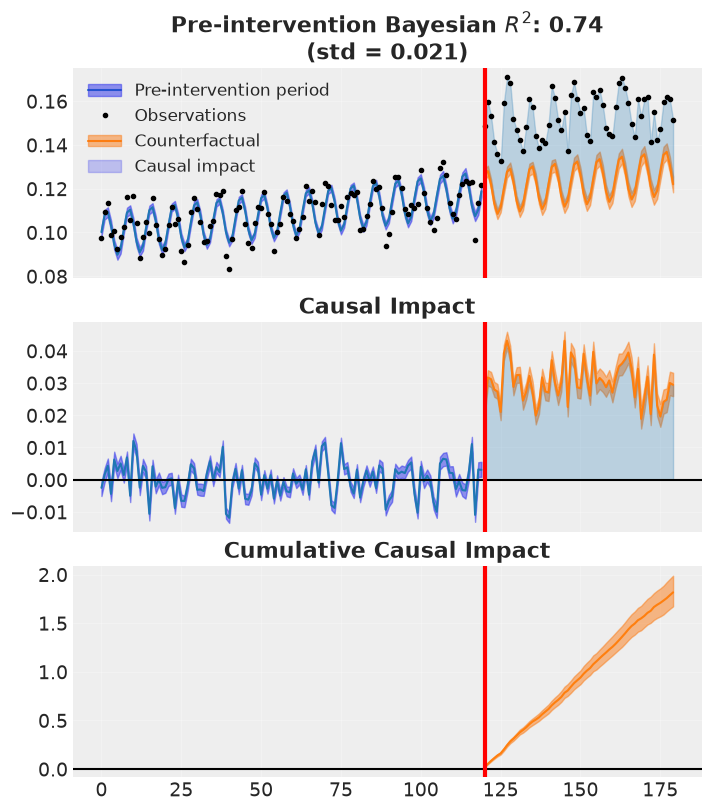

recovered average step +3.0pp vs true +3pp


In [5]:
fig1, _ = result.plot()
try: fig1.set_size_inches(9, 5)
except Exception: pass
print(f"recovered average step +{avg_impact.mean()*100:.1f}pp vs true +{true_lift*100:.0f}pp")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [beta, y_hat_sigma]


Sampling 2 chains for 200 tune and 200 draw iterations (400 + 400 draws total) took 1 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


placebo-in-time +0.0% (≈0, no spurious pre-effect)  ·  residual ACF: 0/10 lags outside the ±2/√n band (lag-1 +0.09) → residuals ≈ white, so the model's intervals are not understated.


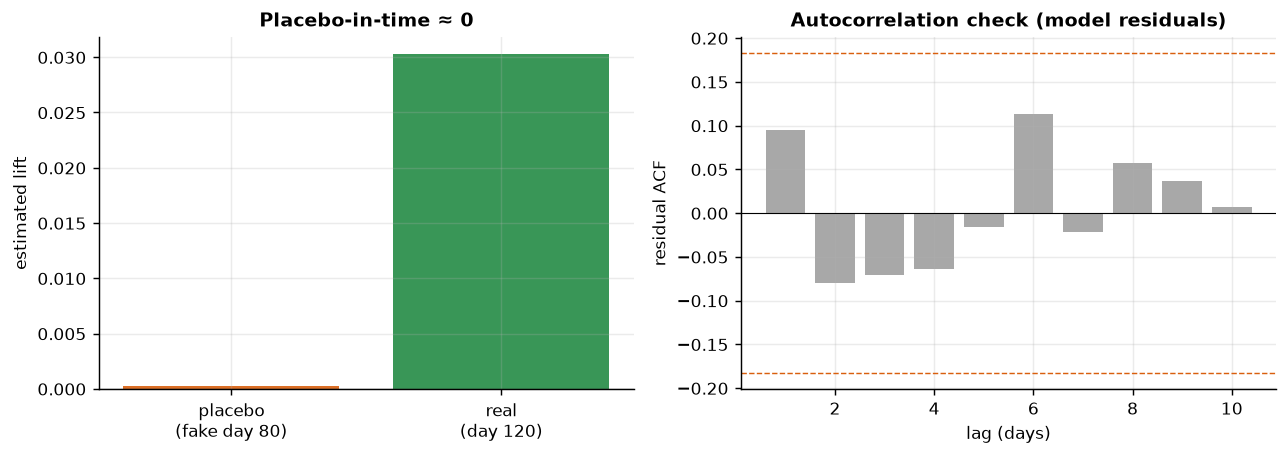

In [6]:
# placebo-in-time: fake redesign at day 80 (before the real one)
FAKE = 80
pre = df[df.t < REDESIGN].copy()
res_p = est.its(pre.set_index("t", drop=False), treatment_time=FAKE, formula="conversion ~ 1 + t + sin7 + cos7", fast=FAST)
placebo = res_p.post_impact.mean(dim=["treated_units","obs_ind"]).values.mean()

# Residual autocorrelation on the pre-period fit — residuals from the SAME model the
# ITS uses (conversion ~ 1 + t + sin7 + cos7), NOT a centred rolling mean. A rolling
# mean removes level/trend but leaves the weekly sin7/cos7 cycle IN, so its "residual"
# ACF shows a big spurious lag-7 spike for seasonality the model already fits. Only the
# model residual is the honest check on whether uncertainty is understated.
Dpre = np.column_stack([np.ones(len(pre)), pre.t.values, pre.sin7.values, pre.cos7.values])
beta_pre, *_ = np.linalg.lstsq(Dpre, pre.conversion.values, rcond=None)
resid = pre.conversion.values - Dpre @ beta_pre
def acf(x, k): x=x-x.mean(); return np.correlate(x[:-k], x[k:])[0]/np.correlate(x,x)[0]
lags = range(1, 11); acfs = [acf(resid, k) for k in lags]
band = 2/np.sqrt(len(resid))

# Cumulative impact is already in CausalPy's own plot above, so we don't repeat it here —
# this figure adds the two checks that plot does NOT: the placebo and the residual ACF.
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].axhline(0, color="k", lw=0.6); ax[0].bar(["placebo\n(fake day 80)","real\n(day 120)"], [placebo, avg_impact.mean()],
    color=[plots.ORANGE, plots.GREEN], alpha=0.9); ax[0].set_ylabel("estimated lift"); ax[0].set_title("Placebo-in-time ≈ 0")
ax[1].bar(list(lags), acfs, color=plots.GREY, alpha=0.85); ax[1].axhline(0, color="k", lw=0.6)
ax[1].axhline(band, color=plots.ORANGE, ls="--", lw=0.8); ax[1].axhline(-band, color=plots.ORANGE, ls="--", lw=0.8)
ax[1].set_xlabel("lag (days)"); ax[1].set_ylabel("residual ACF"); ax[1].set_title("Autocorrelation check (model residuals)")
fig.tight_layout()
n_out = int(np.sum(np.abs(acfs) > band))
print(f"placebo-in-time +{placebo:.1%} (≈0, no spurious pre-effect)  ·  residual ACF: {n_out}/10 lags outside the "
      f"±2/√n band (lag-1 {acfs[0]:+.2f}) → residuals ≈ white, so the model's intervals are not understated.")
plt.show()

**How to read this.** *Left* — the key falsification: we re-ran the whole method with a
**fake** redesign date back in the pre-period; the fake effect is ≈ 0, so the method isn't inventing lift
where none exists. If this bar had been large, our real estimate would be suspect. *Right* — the residual
autocorrelation (ACF) of the **model's own residuals** (after fitting the same trend + weekly-seasonality
terms the ITS uses): essentially every bar sits inside the ±2/√n band, so successive days are effectively
uncorrelated and the model's intervals are not understated. (Computing this ACF on a crude rolling-mean
"residual" instead would leave the weekly cycle in and fake an alarming lag-7 spike — a self-inflicted false
alarm we avoid by residualising against the actual model.) The cumulative-impact view lives in CausalPy's own fit figure above, not in this two-panel check.

### 5b · What a failed diagnostic looks like — drop the seasonality on purpose

Every check so far came back green — which teaches you nothing about what an *alarm* looks like.
Section 4 claimed the `formula` matters ("get the seasonality wrong and the counterfactual is
wrong"). Let's cash that promise: fit the *same data* with the deliberately wrong formula
`conversion ~ 1 + t` — no `sin7`/`cos7` — and watch the residual-ACF instrument fire at lag 7.

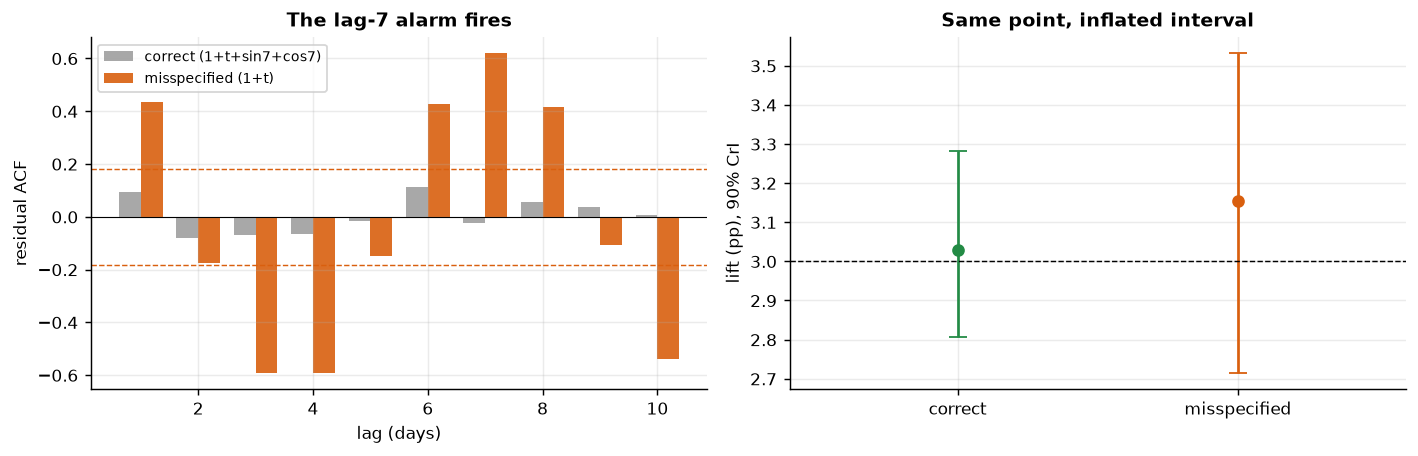

misspecified fit: lag-7 residual ACF +0.62, far outside the ±0.18 band (correct model: -0.02) — the alarm fires.
residual sd 0.0089 vs 0.0052 (x1.7)  ·  lift +3.15pp vs +3.03pp  ·  90% CrI width 0.82pp vs 0.47pp (x1.7).


In [7]:
# Deliberate misspecification: same data, seasonality dropped from the formula
import logging
_pml = logging.getLogger("pymc"); _pml_lvl = _pml.level   # silence this refit's sampler chatter
_pml.setLevel(logging.CRITICAL + 1)                       # (same disclosed trick as the seed-sweep cell)
res_bad = est.its(df, treatment_time=redesign_day, formula="conversion ~ 1 + t", fast=FAST)
im_bad = res_bad.post_impact.mean(dim=["treated_units", "obs_ind"]).values.ravel()
_pml.setLevel(_pml_lvl)

# residual ACF of the misspecified pre-period fit (same lstsq residualisation as above)
Dbad = np.column_stack([np.ones(len(pre)), pre.t.values])
bbad, *_ = np.linalg.lstsq(Dbad, pre.conversion.values, rcond=None)
resid_bad = pre.conversion.values - Dbad @ bbad
acfs_bad = [acf(resid_bad, k) for k in lags]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
w = 0.38
ax[0].bar([k - w/2 for k in lags], acfs, width=w, color=plots.GREY, alpha=0.85, label="correct (1+t+sin7+cos7)")
ax[0].bar([k + w/2 for k in lags], acfs_bad, width=w, color=plots.ORANGE, alpha=0.9, label="misspecified (1+t)")
ax[0].axhline(0, color="k", lw=0.6)
ax[0].axhline(band, color=plots.ORANGE, ls="--", lw=0.8); ax[0].axhline(-band, color=plots.ORANGE, ls="--", lw=0.8)
ax[0].set_xlabel("lag (days)"); ax[0].set_ylabel("residual ACF"); ax[0].legend(fontsize=8)
ax[0].set_title("The lag-7 alarm fires")
for i, (lab, im, col) in enumerate([("correct", avg_impact, plots.GREEN), ("misspecified", im_bad, plots.ORANGE)]):
    lo, hi = np.quantile(im, [0.05, 0.95])
    ax[1].errorbar([i], [im.mean()*100], yerr=[[(im.mean()-lo)*100], [(hi-im.mean())*100]],
                   fmt="o", color=col, capsize=5, ms=6)
ax[1].axhline(true_lift*100, color="k", ls="--", lw=0.8)
ax[1].set_xticks([0, 1]); ax[1].set_xticklabels(["correct", "misspecified"]); ax[1].set_xlim(-0.6, 1.6)
ax[1].set_ylabel("lift (pp), 90% CrI"); ax[1].set_title("Same point, inflated interval")
fig.tight_layout(); plt.show()

w_ok = (np.quantile(avg_impact, .95) - np.quantile(avg_impact, .05)) * 100
w_bad = (np.quantile(im_bad, .95) - np.quantile(im_bad, .05)) * 100
print(f"misspecified fit: lag-7 residual ACF {acfs_bad[6]:+.2f}, far outside the ±{band:.2f} band "
      f"(correct model: {acfs[6]:+.2f}) — the alarm fires.")
print(f"residual sd {resid_bad.std():.4f} vs {resid.std():.4f} (x{resid_bad.std()/resid.std():.1f})  ·  "
      f"lift {im_bad.mean()*100:+.2f}pp vs {avg_impact.mean()*100:+.2f}pp  ·  "
      f"90% CrI width {w_bad:.2f}pp vs {w_ok:.2f}pp (x{w_bad/w_ok:.1f}).")

**How to read this.** *Left* — the ACF panel of Section 5 is not decoration; it is *the*
instrument that detects a missing seasonal term, and this is what it looks like when it fires: the
misspecified model's residuals show the textbook signature of unmodelled weekly seasonality — a
large positive spike at lag 7, several times the $\pm 2/\sqrt n$ band, with the half-cycle dip
before it — while the correct model's bars stay inside the band. *Right* — the damage here is
honest but real: the unmodelled sine lands in the residual, so $\hat\sigma$ inflates (printed
above) and the credible interval widens with it; the *point* estimate barely moves only because the
weekly cycle happens to nearly average out over this post-window. With a post-window that is not a
whole number of weeks — or seasonality larger relative to the effect — the point estimate itself
shifts. The lesson: when the lag-7 bar jumps the band, fix the formula *before* trusting either the
number or the band.

### 5c · Earn the extrapolation — a pre-period backtest, and how much history is enough

The whole method is a forecast, so **rehearse the forecast where it can still be graded**: hold out
the last 30 pre-period days, fit the same formula on days 0–89 only, and let it extrapolate over
days 90–119 exactly as the real fit extrapolates past day 120. Mechanically this reuses the placebo
machinery — a fake "treatment" at day 90 whose post-"treatment" band *is* the 30-day held-out
forecast. If the model cannot forecast pre-period days drawn from the very regime it was fitted on,
its post-period counterfactual is worthless. We score the **empirical coverage of the 90%
posterior-predictive band** over the 30 held-out days (target ≈ 27/30) and the **mean forecast
error** (target ≈ 0). Note the band we score is the *predictive* one (parameter uncertainty *plus*
day-to-day noise $\sigma$) — CausalPy's impact summaries subtract the noise-free $\mu$, which is
the right object for effect size but the wrong one for grading day-level forecasts.

Alongside, the sample-size question this design lives or dies on: refit using only the **last $L$
pre-period days** and watch what shortening the history does to the estimate.

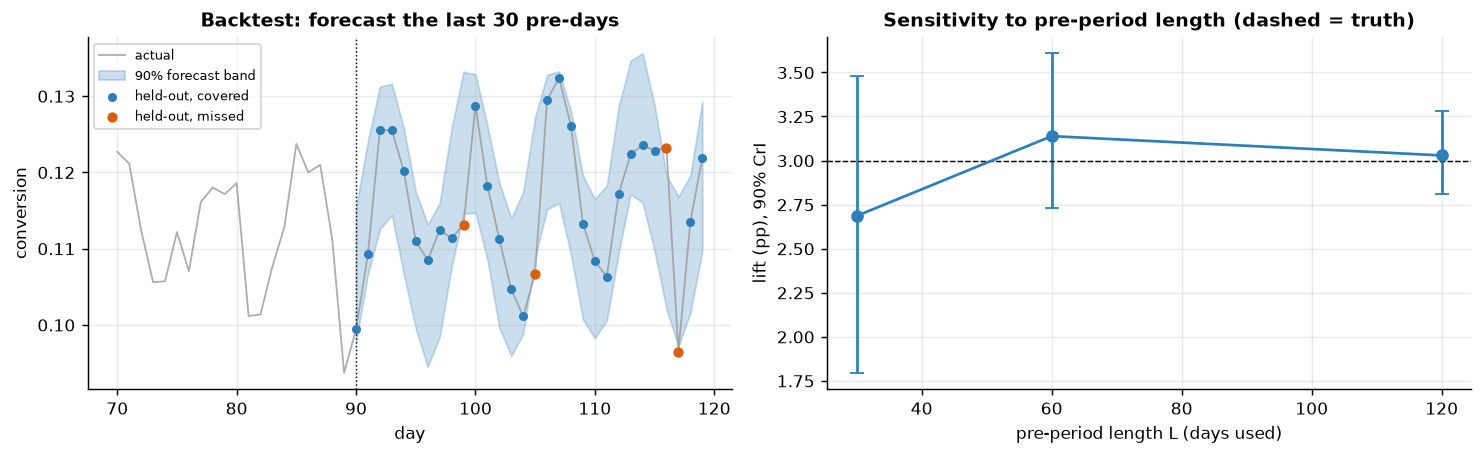

backtest: 90% band covers 26/30 held-out days (87%; nominal 90%)  ·  mean forecast error +0.03pp (≈ 0 → the extrapolation does not drift)
  last  30 pre-days: lift +2.69pp   90% CrI [+1.79, +3.48]   width 1.68pp
  last  60 pre-days: lift +3.14pp   90% CrI [+2.73, +3.61]   width 0.88pp
  last 120 pre-days: lift +3.03pp   90% CrI [+2.81, +3.28]   width 0.47pp


In [8]:
# (a) Backtest: fit on days 0-89, forecast the held-out days 90-119 (last 30 pre-days)
import logging
_pml = logging.getLogger("pymc"); _pml_lvl = _pml.level   # silence the refits' sampler chatter
_pml.setLevel(logging.CRITICAL + 1)                       # (disclosed; restored at the end of the cell)
HOLD = 30
pre_all = df[df.t < REDESIGN].copy().set_index("t", drop=False)
bt = est.its(pre_all, treatment_time=REDESIGN - HOLD, formula="conversion ~ 1 + t + sin7 + cos7", fast=True)
# score the POSTERIOR-PREDICTIVE band (y_hat: mu + observation noise), not post_impact (which uses mu only)
yh = bt.post_pred.posterior_predictive["y_hat"].isel(treated_units=0).stack(s=("chain", "draw")).values
blo, bhi = np.quantile(yh, [0.05, 0.95], axis=-1)
held = pre_all[pre_all.t >= REDESIGN - HOLD]
covered = (held.conversion.values >= blo) & (held.conversion.values <= bhi)
fc_err = held.conversion.values - yh.mean(axis=-1)

# (b) Pre-period-length sensitivity: same fit, keeping only the last L pre-days
lengths = [30, 60, 120] if FAST else [30, 60, 90, 120]
sweep = []
for L in lengths:
    sub = df[df.t >= REDESIGN - L].copy().set_index("t", drop=False)
    r = est.its(sub, treatment_time=REDESIGN, formula="conversion ~ 1 + t + sin7 + cos7", fast=True)
    im = r.post_impact.mean(dim=["treated_units", "obs_ind"]).values.ravel()
    sweep.append((L, im.mean(), np.quantile(im, 0.05), np.quantile(im, 0.95)))
_pml.setLevel(_pml_lvl)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.6))
ctx = pre_all[pre_all.t >= 70]                                     # a little pre-cutoff context
ax[0].plot(ctx.t, ctx.conversion, color=plots.GREY, lw=1.0, alpha=0.8, label="actual")
ax[0].fill_between(held.t, blo, bhi, color=plots.BLUE, alpha=0.25, label="90% forecast band")
ax[0].scatter(held.t[covered], held.conversion[covered], s=16, color=plots.BLUE, zorder=3, label="held-out, covered")
if (~covered).any():
    ax[0].scatter(held.t[~covered], held.conversion[~covered], s=22, color=plots.ORANGE, zorder=3, label="held-out, missed")
ax[0].axvline(REDESIGN - HOLD, color="k", ls=":", lw=0.8)
ax[0].set_xlabel("day"); ax[0].set_ylabel("conversion"); ax[0].legend(fontsize=7, loc="upper left")
ax[0].set_title(f"Backtest: forecast the last {HOLD} pre-days")
Ls = [s[0] for s in sweep]; ms = np.array([s[1] for s in sweep]); los = np.array([s[2] for s in sweep]); his = np.array([s[3] for s in sweep])
ax[1].errorbar(Ls, ms*100, yerr=[(ms-los)*100, (his-ms)*100], fmt="o-", color=plots.BLUE, capsize=4)
ax[1].axhline(true_lift*100, color="k", ls="--", lw=0.8)
ax[1].set_xlabel("pre-period length L (days used)"); ax[1].set_ylabel("lift (pp), 90% CrI")
ax[1].set_title("Sensitivity to pre-period length (dashed = truth)")
fig.tight_layout(); plt.show()

print(f"backtest: 90% band covers {covered.sum()}/{HOLD} held-out days ({covered.mean():.0%}; nominal 90%)  ·  "
      f"mean forecast error {fc_err.mean()*100:+.2f}pp (≈ 0 → the extrapolation does not drift)")
for L, m, lo, hi in sweep:
    print(f"  last {L:>3} pre-days: lift {m*100:+.2f}pp   90% CrI [{lo*100:+.2f}, {hi*100:+.2f}]   width {(hi-lo)*100:.2f}pp")

**How to read this.** *Left* — the rehearsal passed: the held-out days scatter through the 90%
forecast band at roughly the nominal rate (tally printed above; with only 30 held-out days, a few
either side of 27 is binomial noise) and the mean forecast error is ≈ 0, so the
level + trend + weekly-cycle shape extrapolates 30 days ahead without drifting. This is the single
most direct "earn the right to extrapolate" check ITS has — and it is exactly a rehearsal: the
day-120 counterfactual is the same forecast pushed 60 days instead of 30, into a window where no
grading is possible. *Right* — shortening the history doesn't (here) *bias* the estimate, it
*blinds* it: the point estimate stays near the truth at every $L$, wobbling within its own
interval, while the CrI widens sharply at $L = 30$ (printed above — several times the full-history
width). With only ~4 weekly cycles the slope is barely identified, so trend and step blur into each
other. On real data a short window can also bias you outright if it happens to sit on a local
anomaly — the regression-to-the-mean trap of Section 3. A long, boring pre-period is a feature, not
a cost.

### 5d · Recovery across many seeds — unbiased *and* calibrated?

A single sample can land a little off; the real test is whether the estimator is **centred on the truth over repeated samples** and whether its 90% interval **covers** the truth at the stated rate. We refit on many fresh samples (a small fast fit each; their sampler chatter is silenced below, and we read only the aggregate bias/coverage tallies) and check both.

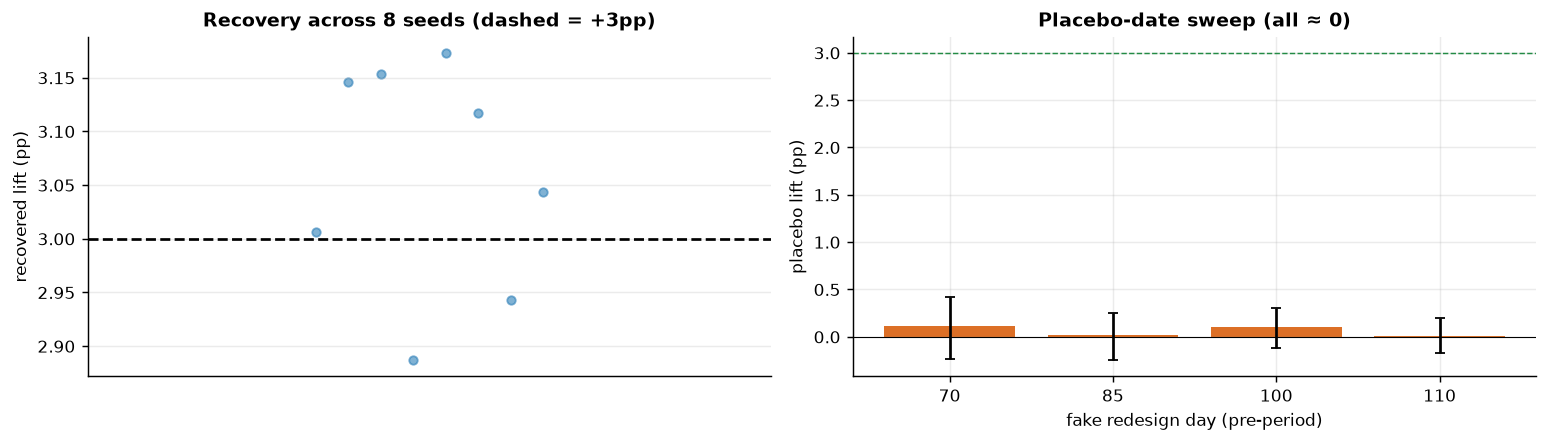

ITS across 8 seeds: mean +3.06pp (true +3pp)  bias +0.06pp  sd 0.10pp  ·  90% interval covers truth in 8/8 seeds.
Placebo-date sweep (pre-period fakes): day 70 +0.11pp, day 85 +0.02pp, day 100 +0.10pp, day 110 +0.01pp — all near zero, so the method doesn't manufacture effects where none exist.


In [9]:
# --- Recovery across many seeds + a placebo-DATE sweep (not just one fake date) ---
NSEED = 8 if FAST else 20
import logging
_pml = logging.getLogger("pymc"); _pml_lvl = _pml.level   # silence the per-seed refits' sampler chatter
_pml.setLevel(logging.CRITICAL + 1)                       # (disclosed above; the same trick pymc's own
# _quiet_logging uses — the low-ESS notice is logged at ERROR level); restored at the end of the cell
pts = []; cov = 0
for sd in range(NSEED):
    d, tl, rday = dgp.its_redesign(n_days=180, redesign_day=REDESIGN, seed=100 + sd)
    r = est.its(d, treatment_time=rday, formula="conversion ~ 1 + t + sin7 + cos7", fast=True)
    im = r.post_impact.mean(dim=["treated_units", "obs_ind"]).values.ravel()
    pts.append(im.mean()); lo, hi = np.quantile(im, [.05, .95]); cov += int(lo <= tl <= hi)
pts = np.array(pts)
fake_dates = [70, 85, 100, 110]                       # fake redesigns on the pre-period; all should land ~0
pre_only = df[df.t < REDESIGN].copy().set_index("t", drop=False)
placebo_draws = [est.its(pre_only, treatment_time=fd, formula="conversion ~ 1 + t + sin7 + cos7", fast=True)
                 .post_impact.mean(dim=["treated_units", "obs_ind"]).values.ravel() for fd in fake_dates]
placebo_by_date = [d.mean() for d in placebo_draws]                       # posterior mean per fake date
placebo_lo = np.array([np.quantile(d, 0.05) for d in placebo_draws])      # 5-95% posterior band per placebo fit
placebo_hi = np.array([np.quantile(d, 0.95) for d in placebo_draws])
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].scatter(np.linspace(-0.2, 0.2, NSEED), pts * 100, s=22, color=plots.BLUE, alpha=0.6)
ax[0].axhline(true_lift * 100, color="k", ls="--"); ax[0].set_xticks([]); ax[0].set_xlim(-0.6, 0.6)
ax[0].set_ylabel("recovered lift (pp)"); ax[0].set_title(f"Recovery across {NSEED} seeds (dashed = +{true_lift*100:.0f}pp)")
ax[1].axhline(0, color="k", lw=0.6)
_pb = np.array(placebo_by_date)
ax[1].bar([str(d) for d in fake_dates], _pb * 100,
          yerr=[(_pb - placebo_lo) * 100, (placebo_hi - _pb) * 100], capsize=3, color=plots.ORANGE, alpha=0.9)
ax[1].axhline(true_lift * 100, color=plots.GREEN, ls="--", lw=0.8)
ax[1].set_xlabel("fake redesign day (pre-period)"); ax[1].set_ylabel("placebo lift (pp)"); ax[1].set_title("Placebo-date sweep (all ≈ 0)")
fig.tight_layout(); plt.show()
print(f"ITS across {NSEED} seeds: mean +{pts.mean()*100:.2f}pp (true +{true_lift*100:.0f}pp)  bias {(pts.mean()-true_lift)*100:+.2f}pp  "
      f"sd {pts.std()*100:.2f}pp  ·  90% interval covers truth in {cov}/{NSEED} seeds.")
_pml.setLevel(_pml_lvl)
print("Placebo-date sweep (pre-period fakes): " + ", ".join(f"day {d} {p*100:+.2f}pp" for d, p in zip(fake_dates, placebo_by_date))
      + " — all near zero, so the method doesn't manufacture effects where none exist.")

**How to read this.** *Left* — the dots scatter tightly around the dashed truth: the printed bias
sits within a few hundredths of a pp of zero and the seed-to-seed sd is tiny next to the +3pp
effect, so the estimator is *centred* over repeated samples, not just lucky on seed 31. *Coverage* — a calibrated
90% interval should "miss" the truth about one seed in ten, so with the handful of seeds run here
the printed tally can sit a couple below the nominal count without any alarm: it is binomial noise
on a small number of trials (for 20 trials, anything from roughly 16 to 20 hits is consistent with
calibration; for 8 trials, 6 to 8). Read it as "consistent with calibrated", not as a precise
coverage estimate. *Right* — the placebo-date sweep generalises Section 5's single day-80 placebo:
no fake date manufactures lift, every bar hugs zero with its posterior interval, and the green
dashed line shows how far all of them sit from the real signal.

### 5e · When ITS lies — a concurrent shock

Everything above can pass while the answer is *wrong*, because every diagnostic so far tests the
same thing — the **pre-period model** — and the identification assumption lives in the
**post-period**. It is untestable from the data, so the only honest way to teach it is to break it
on purpose: same DGP, same +3pp redesign, but an **unrelated +2pp shock** (a competitor outage, a
press mention, a coincident price cut) lands on the redesign date. The redesign is worth +3pp; what
does ITS report — and do any of our checks notice?

In [10]:
# Same series + an UNRELATED +2pp shock arriving with the redesign (worst case: the same date)
import logging
_pml = logging.getLogger("pymc"); _pml_lvl = _pml.level   # silence sampler chatter (disclosed; restored below)
_pml.setLevel(logging.CRITICAL + 1)
d2, tl2, rd2 = dgp.its_redesign(n_days=180, redesign_day=REDESIGN, true_lift=TRUE, seed=SEED)
SHOCK = 0.02
d2.loc[d2.t >= REDESIGN, "conversion"] += SHOCK           # nothing to do with the redesign
res_shock = est.its(d2.set_index("t", drop=False), treatment_time=REDESIGN,
                    formula="conversion ~ 1 + t + sin7 + cos7", fast=FAST)
im_shock = res_shock.post_impact.mean(dim=["treated_units", "obs_ind"]).values.ravel()
# ... and every in-sample diagnostic still passes: the day-80 placebo (the pre-period is unchanged) + convergence
pre_shock = d2[d2.t < REDESIGN].copy().set_index("t", drop=False)
pl_shock = est.its(pre_shock, treatment_time=FAKE, formula="conversion ~ 1 + t + sin7 + cos7",
                   fast=True).post_impact.mean(dim=["treated_units", "obs_ind"]).values.mean()
_pml.setLevel(_pml_lvl)
lo_s, hi_s = np.quantile(im_shock, [0.05, 0.95])
print(f"ITS on the shocked series: +{im_shock.mean()*100:.1f}pp   90% CrI [+{lo_s*100:.1f}pp, +{hi_s*100:.1f}pp]")
print(f"true redesign effect +{TRUE*100:.0f}pp, unrelated shock +{SHOCK*100:.0f}pp -> ITS books the SUM to the redesign; "
      f"CrI contains the true +{TRUE*100:.0f}pp? {'yes' if lo_s <= TRUE <= hi_s else 'NO — confidently wrong'}")
print(f"placebo at day {FAKE} on the shocked series: {pl_shock*100:+.2f}pp (still ≈ 0 — the falsification test PASSES)")
print(f"convergence on the shocked fit: {est.convergence_report(res_shock.idata)['summary']} — all green")

ITS on the shocked series: +5.0pp   90% CrI [+4.8pp, +5.3pp]
true redesign effect +3pp, unrelated shock +2pp -> ITS books the SUM to the redesign; CrI contains the true +3pp? NO — confidently wrong
placebo at day 80 on the shocked series: +0.02pp (still ≈ 0 — the falsification test PASSES)
convergence on the shocked fit: max r-hat 1.010 - min ESS 254 - divergences 0 — all green


**The uncomfortable lesson.** ITS reports the *combined* effect with a tight interval that — as
the print shows — excludes the true +3pp entirely: **confidently wrong**. And nothing flinched: the
sampler converged, the pre-period fit is as good as ever, and the placebo *still passes*, because
the pre-period is untouched by a post-period shock. That is the precise scope of each tool:

- the **placebo** validates the *pre-period model* ("does the method invent lift where none
  exists?"), not the *post-period attribution*;
- the **credible interval** covers *sampling noise* ("how precisely do we know the gap between
  actual and counterfactual?"), not *identification error* ("is the gap all redesign?").

No statistic computed from this series can split +3pp of redesign from +2pp of coincident shock —
they are observationally identical. The defenses are outside the data: the **calendar audit** named
in the caveats (pricing, campaigns, competitor moves, PR, tracking changes in the launch window), or
better, a *design* fix — stagger the rollout so DiD applies (notebook 08) or keep a holdout
geography for synthetic control (notebook 07). What you *can* do inside the analysis is quantify
**headroom**: Section 6's robustness line computes how large a coincident shock would have to be
before the business call flips — the honest replacement for pretending the assumption is testable.

## 6 · Decide, in euros — keep or roll back?

A redesign lift is rarely permanent — **novelty fades**. Projecting the measured 60-day lift *flat* across a
whole year (a naive `lift × visitors × value × 365`) contradicts this notebook's own "uncertainty grows with
horizon" message. So we decide against an explicit **redesign cost** and sweep the **persistence**: the effect
decays with a novelty half-life, and we discount future days accordingly (effective days
$=\sum_t 0.5^{\,t/\text{half-life}}$). For each persistence scenario we report the annual value and
**P(annual value > cost)**. The 0.9 go/no-go bar is the cookbook's convention — act only when the posterior is
at least 90% sure the value clears the cost.

We report two kinds of euros and keep them separate. The **realized** 60-day impact is the
cumulative posterior $C_T$ from Section 4 converted to money — a fact about the observed window,
no persistence assumption needed. The **projected** annual value is assumption-laden: it needs a
persistence guess, which is exactly what the sweep makes explicit. Realized first.

In [11]:
DAILY_VISITORS, VALUE, HORIZON = 8000, 40.0, 365
REDESIGN_COST = 600_000.0             # amortized build + one year of maintenance (a stated assumption)
daily_value = avg_impact * DAILY_VISITORS * VALUE     # € per day at the full (undecayed) lift, per draw
p_pos = (avg_impact > 0).mean()

# Realized (already banked) impact over the observed 60 post days: the cumulative posterior C_T in euros.
# cum_impact is per-draw cumulative pp-days; its final column is C_T = sum of daily gaps over the window.
cum_final = cum_impact[:, -1]
extra_conv = cum_final * DAILY_VISITORS               # summed daily lift x visitors/day = extra conversions
eur_realized = extra_conv * VALUE
print(f"Realized 60-day impact (fact, no persistence assumption): {extra_conv.mean():,.0f} extra conversions "
      f"(90% CrI [{np.quantile(extra_conv, .05):,.0f}, {np.quantile(extra_conv, .95):,.0f}]) "
      f"= €{eur_realized.mean():,.0f} [€{np.quantile(eur_realized, .05):,.0f}, €{np.quantile(eur_realized, .95):,.0f}] "
      f"already banked — {eur_realized.mean()/REDESIGN_COST:.0%} of the €{REDESIGN_COST:,.0f} cost in 60 days.\n")

# Persistence sweep: novelty-driven lift decays. Effective days = sum_t 0.5**(t / half_life),
# so a permanent effect keeps all 365 days while a fast-fading one keeps far fewer.
def effective_days(h, H=HORIZON):
    if np.isinf(h): return float(H)
    return float(np.sum(0.5 ** (np.arange(H) / h)))
scenarios = [(np.inf, "no decay"), (180.0, "6-month"), (90.0, "3-month"), (30.0, "1-month")]
verdicts = {}                                  # keep each scenario's table verdict for the summary below

print(f"Undecayed lift: {avg_impact.mean()*DAILY_VISITORS:,.0f} extra conversions/day  ·  €{daily_value.mean():,.0f}/day")
print(f"Assumed amortized redesign cost: €{REDESIGN_COST:,.0f}/year\n")
print(f"{'novelty half-life':>18} | {'eff. days':>9} | {'annual value':>13} | {'P(value>cost)':>13} | verdict")
for h, lab in scenarios:
    ed = effective_days(h); annual_h = daily_value * ed; p_cost = (annual_h > REDESIGN_COST).mean()
    verdict = "KEEP" if p_cost > 0.9 else ("roll back/renew" if p_cost < 0.5 else "renew & re-test")
    verdicts[lab] = verdict
    print(f"{lab:>18} | {ed:9.0f} | €{annual_h.mean():>12,.0f} | {p_cost:>13.2f} | {verdict}")

be_lift = REDESIGN_COST / (DAILY_VISITORS * VALUE * HORIZON)
print(f"\nBreak-even lift (no decay): {be_lift*100:.2f}pp of conversions covers the €{REDESIGN_COST:,.0f} cost; "
      f"we estimate {avg_impact.mean()*100:.1f}pp.")
print(f"P(redesign helped at all) {'>0.99' if p_pos > 0.99 else f'{p_pos:.2f}'} ({avg_impact.size:,} draws) → "
      f"KEEP under any realistic persistence; the harsh 1-month half-life is the exception — the table's own "
      f"call there is '{verdicts['1-month']}'.")
lo90pp = np.quantile(avg_impact, 0.05) * 100
print(f"Robustness to concurrent shocks: even at the conservative +{lo90pp:.1f}pp lower bound of the 90% credible "
      f"interval, a coincident shock would need to explain more than +{lo90pp - be_lift*100:.1f}pp of the measured "
      f"lift before the no-decay annual value falls to the €{REDESIGN_COST:,.0f} break-even ({be_lift*100:.2f}pp) "
      f"— wide headroom for the KEEP call.")

Realized 60-day impact (fact, no persistence assumption): 14,539 extra conversions (90% CrI [13,478, 15,752]) = €581,542 [€539,103, €630,077] already banked — 97% of the €600,000 cost in 60 days.

Undecayed lift: 242 extra conversions/day  ·  €9,692/day
Assumed amortized redesign cost: €600,000/year

 novelty half-life | eff. days |  annual value | P(value>cost) | verdict
          no decay |       365 | €   3,537,714 |          1.00 | KEEP
           6-month |       196 | €   1,903,382 |          1.00 | KEEP
           3-month |       123 | €   1,187,358 |          1.00 | KEEP
           1-month |        44 | €     424,266 |          0.00 | roll back/renew

Break-even lift (no decay): 0.51pp of conversions covers the €600,000 cost; we estimate 3.0pp.
P(redesign helped at all) >0.99 (400 draws) → KEEP under any realistic persistence; the harsh 1-month half-life is the exception — the table's own call there is 'roll back/renew'.
Robustness to concurrent shocks: even at the conservative 

**Read-out.** The verdict is one-sided in this run, and the table shows why: the measured **+3pp**
lift is roughly six times the **0.51pp** break-even, so even a 3-month novelty half-life — which
keeps only ~123 effective days of the 365 — still leaves ≈ €1.2M of annual value against the €600k
cost at P ≈ 1.00 → **KEEP**. The single exception is the most instructive row: under a harsh
1-month half-life the lift burns out before it pays (P ≈ 0.00 → *roll back/renew*). Notice what
just happened to the decision: it no longer hinges on *whether* the redesign worked (it did —
P(helped at all) > 0.99) but on **how long the lift persists** — a parameter the 60-day posterior
cannot identify, because decay reveals itself only over a longer horizon. That's why the honest
deliverable is the persistence *table* plus a monitoring plan (re-estimate the lift at day 120/180
and watch which row you're living in), not a single annualised number.

One number in the print block deserves top billing: the **realized** 60-day impact — the cumulative
posterior converted to money — recovers most of the €600k build cost within the observed window
alone, before any persistence assumption is invoked. Separating *realized* (a fact of the window we
watched) from *projected* (a bet on the half-life) is the CMO-grade distinction the persistence
table then builds on.

> **Memo to the CMO.**
>
> - The redesign works: P(lift > 0) > 0.99, and the measured lift is several times the ~0.5pp
>   break-even.
> - Sixty days in, the redesign has already paid back most of its €600k cost in *realized*
>   conversion value (print above) — that part is banked, whatever novelty does next.
> - Projected annual value clears the cost under every persistence scenario except a 1-month
>   novelty burn-out: the open question is *how long the lift lasts*, not *whether it exists*.
>   Re-estimate at day 120 and 180 and watch which table row we are living in.
> - The estimate is only as good as the launch calendar: ITS books *anything* that changed on
>   day 120 to the redesign (Section 5e). Before banking the number, audit the window for
>   concurrent changes — pricing, campaigns, competitors, tracking.

## 7 · Caveats

- **The no-concurrent-shock assumption is the weak link.** A pricing change or competitor move at the
  redesign date gets attributed to the redesign — Section 5e shows the estimate absorbing an unrelated +2pp shock in
  full while every diagnostic stays green. Vet the calendar around the intervention; no statistic
  can do it for you.
- **Uncertainty grows with horizon** — the band (and cumulative-impact band) widens; long-horizon claims
  are genuinely less certain.
- **A control group beats extrapolation.** If even a small hold-out or comparable untreated series
  exists, DiD (nb 08) or synthetic control (nb 07) are stronger. ITS is the last resort when *everyone*
  was treated.
- **Autocorrelation.** If residuals are autocorrelated (checked above), a naive model understates
  uncertainty; prefer trend/seasonality structure or explicit AR terms.
- **Regression to the mean.** If the redesign shipped *because* conversion had dipped, the
  pre-period fit inherits the dip and the natural rebound is booked as lift. Ask what triggered
  the launch date; if the metric itself did, drop or model the dip window — and expect the
  placebo-date sweep (5d) to light up near it.